# Real-event validation of EQViT magnitude: 2022 M5.4 Coalson earthquake

This notebook validates the TXED-trained `EQViTMagnitude` model on the real 16 November 2022 Coalson earthquake using the uploaded TexNet QuakeML and waveforms downloaded through the TexNet FDSN service.

It is deliberately **EEW-oriented**: it reads the catalog truth and manual P picks from QuakeML, downloads all usable three-component stations, reproduces the training input (**P−1 s to P+29 s at 100 Hz, 3000 samples**), loads the best checkpoint, evaluates station and network magnitudes, performs waveform/amplitude/QC diagnostics, and makes a causal P+29 s network-convergence analysis.

**Critical amplitude caveat.** The training notebook preserves amplitude (only the component mean is removed). Therefore this notebook does not normalize each trace. Any scaling mismatch between TXED and newly downloaded MiniSEED is a real deployment-domain-shift issue and should remain visible.

In [1]:
from pathlib import Path
import json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

try:
    from obspy import read_events, read
    from obspy.clients.fdsn import Client
except ImportError as e:
    raise ImportError("Install ObsPy first: pip install obspy") from e

from eqvit_torch.models import EQViTMagnitude

SEED=2026
rng=np.random.default_rng(SEED)
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE="cuda" if torch.cuda.is_available() else ("mps" if getattr(torch.backends,"mps",None) and torch.backends.mps.is_available() else "cpu")
print("PyTorch:",torch.__version__,"| device:",DEVICE)

PyTorch: 2.10.0 | device: mps


## 1. Paths and locked 30-s inference configuration

In [2]:
QML_PATH=Path("texnet2022wmmd.qml")
if not QML_PATH.exists():
    QML_PATH=Path("/mnt/data/texnet2022wmmd.qml")

CHECKPOINT_CANDIDATES=[
    Path("./outputs/txed_eqvit_magnitude_v0/txed_eqvit_magnitude_best.pt"),
    Path("./outputs/txed_eqvit_magnitude/txed_eqvit_magnitude_best.pt"),
]
BEST=next((p for p in CHECKPOINT_CANDIDATES if p.exists()),CHECKPOINT_CANDIDATES[0])

OUTPUT_DIR=Path("./outputs/coalson_m54_eqvit_validation")
WAVEFORM_DIR=OUTPUT_DIR/"waveforms"
OUTPUT_DIR.mkdir(parents=True,exist_ok=True); WAVEFORM_DIR.mkdir(parents=True,exist_ok=True)

FS=100.0; PRE_P_S=1.0; POST_P_S=29.0; N_SAMPLES=3000; PRE_P_SAMPLES=100
DOWNLOAD_PRE_S=3.0; DOWNLOAD_POST_S=31.0
ONLY_WEIGHTED_P=False
TRIM_FRACTION=0.10; N_BOOT=5000

print("QML:",QML_PATH)
print("Checkpoint:",BEST)
assert QML_PATH.exists()
assert N_SAMPLES==int((PRE_P_S+POST_P_S)*FS)

QML: texnet2022wmmd.qml
Checkpoint: outputs/txed_eqvit_magnitude_v0/txed_eqvit_magnitude_best.pt


## 2. Read the Coalson event from the uploaded QuakeML

The comparison uses the QuakeML's preferred origin and preferred `ML(TexNet)` magnitude at full stored precision, rather than hard-coding 5.4.

In [3]:
cat=read_events(str(QML_PATH)); event=cat[0]
origin=event.preferred_origin() or event.origins[0]
magnitude=event.preferred_magnitude() or event.magnitudes[0]
TRUE_M=float(magnitude.mag); ORIGIN_TIME=origin.time
EV_LAT=float(origin.latitude); EV_LON=float(origin.longitude); EV_DEPTH_KM=float(origin.depth or 0)/1000
print(event)
print(f"Origin: {ORIGIN_TIME}")
print(f"Location: {EV_LAT:.5f}, {EV_LON:.5f}, depth={EV_DEPTH_KM:.2f} km")
print(f"Truth: {magnitude.magnitude_type}={TRUE_M:.4f}")

Event:	2022-11-16T21:32:44.481830Z | +31.637, -103.999 | 5.43 ML(TexNet) | manual

	                  resource_id: ResourceIdentifier(id="smi:org.gfz-potsdam.de/geofon/texnet2022wmmd")
	                   event_type: 'earthquake'
	         event_type_certainty: 'known'
	                creation_info: CreationInfo(agency_id='TXNet', author='scevent@sc3primary.beg.utexas.edu', creation_time=UTCDateTime(2022, 11, 16, 21, 32, 55, 683979))
	          preferred_origin_id: ResourceIdentifier(id="smi:org.gfz-potsdam.de/geofon/NLL.20221117170218.53264.116304")
	       preferred_magnitude_id: ResourceIdentifier(id="smi:org.gfz-potsdam.de/geofon/Magnitude/20221117170222.739536.116338")
	 preferred_focal_mechanism_id: ResourceIdentifier(id="smi:org.gfz-potsdam.de/geofon/FocalMechanism/20221117003721.714512.92750")
	                         ---------
	           event_descriptions: 1 Elements
	                        picks: 123 Elements
	                      origins: 1 Elements
	                  

## 3. Manual P picks and preferred-origin arrival metadata

In [4]:
arr_by_pick={str(a.pick_id):a for a in origin.arrivals if a.pick_id}
rows=[]
for p in event.picks:
    if (p.phase_hint or "").upper()!="P": continue
    w=p.waveform_id; a=arr_by_pick.get(str(p.resource_id))
    rows.append(dict(
        pick_id=str(p.resource_id),network=w.network_code or "*",station=w.station_code,
        location=w.location_code if w.location_code is not None else "*",
        pick_channel=w.channel_code or "",p_time=p.time,
        distance_deg=float(a.distance) if a is not None and a.distance is not None else np.nan,
        azimuth_deg=float(a.azimuth) if a is not None and a.azimuth is not None else np.nan,
        time_residual_s=float(a.time_residual) if a is not None and a.time_residual is not None else np.nan,
        time_weight=float(a.time_weight) if a is not None and a.time_weight is not None else np.nan))
picks=pd.DataFrame(rows).sort_values("p_time").reset_index(drop=True)
picks["distance_km_approx"]=picks.distance_deg*111.195
picks["p_elapsed_s"]=picks.p_time.map(lambda t:float(t-ORIGIN_TIME))
picks["available_at_elapsed_s"]=picks.p_elapsed_s+POST_P_S
if ONLY_WEIGHTED_P: picks=picks[picks.time_weight.fillna(0)>0].reset_index(drop=True)
print("P picks:",len(picks),"| unique stations:",picks[["network","station"]].drop_duplicates().shape[0])
display(picks)

P picks: 71 | unique stations: 69


,pick_id,network,station,location,pick_channel,p_time,distance_deg,azimuth_deg,time_residual_s,time_weight,distance_km_approx,p_elapsed_s,available_at_elapsed_s
0,smi:org.gfz-potsdam.de/geofon/Pick/20221117015...,TX,PB24,00,HHZ,2022-11-16T21:32:46.157945Z,0.023452,223.866095,-0.036488,1.245844,2.607692,1.676115,30.676115
1,smi:org.gfz-potsdam.de/geofon/Pick/20221117015...,4O,WB03,00,HHN,2022-11-16T21:32:46.256619Z,0.036511,135.827024,-0.048001,1.230867,4.059882,1.774789,30.774789
2,smi:org.gfz-potsdam.de/geofon/Pick/20221117164...,TX,PB40,00,HNZ,2022-11-16T21:32:46.536693Z,0.055535,84.773108,0.028165,1.262350,6.175177,2.054863,31.054863
3,smi:org.gfz-potsdam.de/geofon/Pick/20221117015...,TX,PB20,00,HHN,2022-11-16T21:32:46.573785Z,0.054426,261.089902,0.056830,1.232800,6.051941,2.091955,31.091955
4,smi:org.gfz-potsdam.de/geofon/Pick/20221116214...,TX,PB34,00,HHZ,2022-11-16T21:32:46.649570Z,0.052030,320.522530,0.176753,0.923594,5.785455,2.167740,31.167740
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,smi:org.gfz-potsdam.de/geofon/Pick/20221116215...,TX,PB30,00,HHZ,2022-11-16T21:32:57.975571Z,0.679060,121.763988,-0.035423,1.091569,75.508093,13.493741,42.493741
67,smi:org.gfz-potsdam.de/geofon/Pick/20221117165...,TX,PB22,00,HHZ,2022-11-16T21:33:01.373076Z,0.948646,116.637436,-1.585059,0.000000,105.484637,16.891246,45.891246
68,smi:org.gfz-potsdam.de/geofon/Pick/20221117165...,TX,PB05,00,HHZ,2022-11-16T21:33:01.729035Z,0.921276,141.269094,-0.761902,0.000000,102.441265,17.247205,46.247205
69,smi:org.gfz-potsdam.de/geofon/Pick/20221117165...,4O,DB03,*,HHZ,2022-11-16T21:33:02.281820Z,0.944432,123.499810,-0.606194,0.000000,105.016099,17.799990,46.799990


## 4. Load the best P−1/P+29 s checkpoint and verify its saved configuration

In [5]:
assert BEST.exists(), f"Checkpoint not found: {BEST}. Edit BEST to your trained txed_eqvit_magnitude_best.pt."
ckpt=torch.load(BEST,map_location=DEVICE)
state=ckpt["state_dict"] if isinstance(ckpt,dict) and "state_dict" in ckpt else ckpt
cfg=ckpt.get("config",{}) if isinstance(ckpt,dict) else {}
if cfg:
    print(json.dumps(cfg,indent=2))
    assert int(cfg.get("window_samples",N_SAMPLES))==N_SAMPLES
    assert int(cfg.get("pre_p_samples",PRE_P_SAMPLES))==PRE_P_SAMPLES
    assert float(cfg.get("sample_rate_hz",FS))==FS
model=EQViTMagnitude().to(DEVICE); model.load_state_dict(state); model.eval()
print("Loaded",BEST)
print("epoch:",ckpt.get("epoch") if isinstance(ckpt,dict) else None,
      "| validation MAE:",ckpt.get("val_mae") if isinstance(ckpt,dict) else None)

{
  "window_samples": 3000,
  "pre_p_samples": 100,
  "sample_rate_hz": 100,
  "p_jitter_samples": 20,
  "event_disjoint": true,
  "balanced_sampling": true
}
Loaded outputs/txed_eqvit_magnitude_v0/txed_eqvit_magnitude_best.pt
epoch: 33 | validation MAE: 0.1615554839372635


## 5. Download all available three-component waveforms

`Client("texnet")` follows the TexNet/ObsPy FDSN access pattern. MiniSEED is cached locally so repeated analyses do not redownload it.

In [6]:
client=Client("texnet")
print(client)

FDSN Webservice Client (base url: http://rtserve.beg.utexas.edu)
Available Services: 'dataselect' (v1.1.3), 'station' (v1.1.5)

Use e.g. client.help('dataselect') for the
parameter description of the individual services
or client.help() for parameter description of
all webservices.


In [7]:
def download_station(row):
    net,sta=row.network,row.station
    loc=row.location if row.location not in (None,"") else "*"
    cache=WAVEFORM_DIR/f"{net}.{sta}.{str(loc).replace('*','ALL')}.mseed"
    if cache.exists() and cache.stat().st_size>0:
        return read(str(cache)),"cache"
    st=client.get_waveforms(net,sta,loc,"*",row.p_time-DOWNLOAD_PRE_S,row.p_time+DOWNLOAD_POST_S,
                            attach_response=False)
    if len(st): st.write(str(cache),format="MSEED")
    return st,"download"

streams={}; logs=[]
for r in picks.itertuples():
    key=(r.network,r.station)
    if key in streams: continue
    try:
        st,src=download_station(r); streams[key]=st
        logs.append(dict(network=r.network,station=r.station,ok=True,n_traces=len(st),source=src,error=""))
        print(f"OK   {r.network}.{r.station}: {len(st)} traces ({src})")
    except Exception as e:
        logs.append(dict(network=r.network,station=r.station,ok=False,n_traces=0,source="",error=repr(e)))
        print(f"FAIL {r.network}.{r.station}: {e}")
download_log=pd.DataFrame(logs); download_log.to_csv(OUTPUT_DIR/"download_log.csv",index=False)
display(download_log)

OK   TX.PB24: 3 traces (download)
OK   4O.WB03: 3 traces (download)
OK   TX.PB40: 6 traces (download)
OK   TX.PB20: 3 traces (download)
OK   TX.PB34: 6 traces (download)
OK   TX.PB23: 3 traces (download)
OK   TX.PB25: 3 traces (download)
OK   TX.PB31: 3 traces (download)
OK   4O.WB01: 4 traces (download)
OK   TX.PB33: 6 traces (download)
OK   4O.WB04: 6 traces (download)
OK   4O.WB02: 3 traces (download)
OK   TX.PB43: 6 traces (download)
FAIL TX.PB13: No data available for request.
HTTP Status code: 204
Detailed response of server:


OK   4O.SA06: 3 traces (download)
OK   4O.WB05: 6 traces (download)
OK   4O.CV01: 3 traces (download)
OK   4O.SA02: 3 traces (download)
OK   4O.SA04: 6 traces (download)
OK   TX.PECS: 6 traces (download)
OK   4O.CT01: 3 traces (download)
OK   TX.PB07: 3 traces (download)
OK   TX.PB11: 6 traces (download)
OK   4O.CT02: 3 traces (download)
OK   4O.WB12: 6 traces (download)
OK   4O.WB11: 6 traces (download)
OK   TX.PB42: 3 traces (download)
OK   TX.PB36: 6 tr

,network,station,ok,n_traces,source,error
0,TX,PB24,True,3,download,
1,4O,WB03,True,3,download,
2,TX,PB40,True,6,download,
3,TX,PB20,True,3,download,
4,TX,PB34,True,6,download,
...,...,...,...,...,...,...
64,TX,PB30,True,3,download,
65,TX,PB22,True,3,download,
66,TX,PB05,True,6,download,
67,4O,DB03,True,3,download,


## 6. Reproduce the training tensor exactly

A complete channel family is selected (prefer `HH`, then `BH`, `EH`, `CH`). Each component is put on the exact 100-Hz P-centered grid. **No max/RMS/standard-deviation normalization and no response removal** are applied. Only the per-component mean is removed, matching the supplied training notebook.

In [8]:
PREFIX_PRIORITY=["HH","BH","EH","CH","HN","SH"]

def choose_three_components(st):
    candidates=[tr for tr in st if len(tr.stats.channel or "")>=3 and tr.stats.channel[-1] in "ZNE12"]
    groups={}
    for tr in candidates:
        groups.setdefault((tr.stats.location or "",tr.stats.channel[:2]),[]).append(tr)
    def score(item):
        (loc,pref),trs=item; suff={tr.stats.channel[-1] for tr in trs}
        complete=("Z" in suff) and ({"N","E"}<=suff or {"1","2"}<=suff)
        pri=PREFIX_PRIORITY.index(pref) if pref in PREFIX_PRIORITY else 99
        return (0 if complete else 1,pri,-max(float(tr.stats.sampling_rate) for tr in trs))
    for _,trs in sorted(groups.items(),key=score):
        by={tr.stats.channel[-1]:tr for tr in trs}
        if "Z" in by and "N" in by and "E" in by: return [by["Z"].copy(),by["N"].copy(),by["E"].copy()]
        if "Z" in by and "1" in by and "2" in by: return [by["Z"].copy(),by["1"].copy(),by["2"].copy()]
    raise ValueError("No complete Z+2-horizontal channel family")

def station_to_window(st,ptime):
    trs=choose_three_components(st); out=[]; chans=[]; fs0=[]
    start=ptime-PRE_P_S
    for tr in trs:
        chans.append(tr.id); fs0.append(float(tr.stats.sampling_rate))
        tr.detrend("constant")
        tr.interpolate(sampling_rate=FS,starttime=start,npts=N_SAMPLES,method="linear")
        x=np.asarray(tr.data,np.float32)
        if x.shape!=(N_SAMPLES,) or not np.isfinite(x).all(): raise ValueError(f"Bad {tr.id}: {x.shape}")
        out.append(x)
    w=np.stack(out,axis=1)
    w=w-w.mean(axis=0,keepdims=True)
    return w.astype(np.float32),chans,fs0

@torch.no_grad()
def infer(w):
    return float(model(torch.from_numpy(np.ascontiguousarray(w))[None].to(DEVICE)).reshape(-1).cpu())

records=[]; rejected=[]; windows={}
for r in picks.itertuples():
    key=(r.network,r.station)
    if key not in streams:
        rejected.append({**r._asdict(),"reason":"download unavailable"}); continue
    try:
        w,chans,fs0=station_to_window(streams[key],r.p_time)
        pm=infer(w); peak=np.max(np.abs(w),axis=0)
        pre=np.sqrt(np.mean(w[:PRE_P_SAMPLES]**2,axis=0))
        sig=np.sqrt(np.mean(w[PRE_P_SAMPLES:]**2,axis=0))
        snr=20*np.log10((np.linalg.norm(sig)+1e-20)/(np.linalg.norm(pre)+1e-20))
        d=r._asdict(); d.update(
            channels=" | ".join(chans),original_fs=" | ".join(f"{x:g}" for x in fs0),
            predicted_magnitude=pm,catalog_magnitude=TRUE_M,residual=pm-TRUE_M,
            abs_error=abs(pm-TRUE_M),peak_vector_counts=float(np.linalg.norm(peak)),snr_proxy_db=float(snr))
        records.append(d); windows[key]=w
    except Exception as e:
        rejected.append({**r._asdict(),"reason":repr(e)})

pred=pd.DataFrame(records); rej=pd.DataFrame(rejected)
assert len(pred)>0,"No valid station tensors. Inspect download_log and rejected stations."
pred.to_csv(OUTPUT_DIR/"station_predictions.csv",index=False)
rej.to_csv(OUTPUT_DIR/"rejected_stations.csv",index=False)
display(pred[["network","station","distance_km_approx","channels","predicted_magnitude","residual","snr_proxy_db"]])
if len(rej): display(rej[["network","station","reason"]])

,network,station,distance_km_approx,channels,predicted_magnitude,residual,snr_proxy_db
0,TX,PB24,2.607692,TX.PB24.00.HHZ | TX.PB24.00.HHN | TX.PB24.00.HHE,4.360403,-1.072576,15.440230
1,4O,WB03,4.059882,4O.WB03.00.HHZ | 4O.WB03.00.HHN | 4O.WB03.00.HHE,4.452445,-0.980534,4.070522
2,TX,PB40,6.175177,TX.PB40.00.HHZ | TX.PB40.00.HH1 | TX.PB40.00.HH2,4.753950,-0.679028,40.178127
3,TX,PB20,6.051941,TX.PB20.00.HHZ | TX.PB20.00.HHN | TX.PB20.00.HHE,4.702084,-0.730894,60.245049
4,TX,PB34,5.785455,TX.PB34.00.HHZ | TX.PB34.00.HH1 | TX.PB34.00.HH2,4.605797,-0.827181,33.032463
5,TX,PB23,7.642546,TX.PB23.00.HHZ | TX.PB23.00.HHN | TX.PB23.00.HHE,1.579711,-3.853267,4.189841
6,TX,PB25,9.032044,TX.PB25.00.HHZ | TX.PB25.00.HHN | TX.PB25.00.HHE,2.066149,-3.366829,6.661481
7,TX,PB31,11.060423,TX.PB31.00.HHZ | TX.PB31.00.HH1 | TX.PB31.00.HH2,4.455034,-0.977944,16.607950
8,4O,WB01,11.113540,4O.WB01.00.HHZ | 4O.WB01.00.HHN | 4O.WB01.00.HHE,4.510924,-0.922054,45.000641
9,TX,PB33,12.497050,TX.PB33.00.HHZ | TX.PB33.00.HH1 | TX.PB33.00.HH2,4.456226,-0.976752,39.425159


,network,station,reason
0,4O,WB04,ValueError('The new array must be fully contai...
1,TX,PB13,download unavailable
2,4O,WB05,ValueError('The new array must be fully contai...
3,4O,SA04,ValueError('The new array must be fully contai...
4,4O,WB12,ValueError('The new array must be fully contai...
5,4O,WB11,ValueError('The new array must be fully contai...
6,4O,WB09,ValueError('The new array must be fully contai...
7,GM,NMP11,download unavailable
8,4O,WB10,ValueError('The new array must be fully contai...
9,4O,WB06,ValueError('The new array must be fully contai...


## 7. Network magnitude and bootstrap uncertainty

In [9]:
def trimmed_mean(x,frac=.10):
    x=np.sort(np.asarray(x,float)); k=int(np.floor(frac*len(x)))
    return float(np.mean(x[k:len(x)-k])) if len(x)-2*k>0 else float(np.mean(x))
v=pred.predicted_magnitude.to_numpy(float)
M_mean=float(np.mean(v)); M_median=float(np.median(v)); M_trim=trimmed_mean(v,TRIM_FRACTION)
boots=np.array([np.median(rng.choice(v,size=len(v),replace=True)) for _ in range(N_BOOT)])
ci_lo,ci_hi=np.quantile(boots,[.025,.975])
summary=dict(catalog_magnitude=TRUE_M,n_usable_stations=len(pred),network_mean=M_mean,
             network_median=M_median,network_trimmed_mean=M_trim,median_error=M_median-TRUE_M,
             median_abs_error=abs(M_median-TRUE_M),bootstrap_median_95pct_ci=[float(ci_lo),float(ci_hi)],
             station_mae=float(pred.abs_error.mean()),station_bias=float(pred.residual.mean()),
             station_rmse=float(np.sqrt(np.mean(pred.residual**2))))
(OUTPUT_DIR/"event_validation_summary.json").write_text(json.dumps(summary,indent=2))
print(json.dumps(summary,indent=2))

{
  "catalog_magnitude": 5.432978086,
  "n_usable_stations": 50,
  "network_mean": 4.535461974143982,
  "network_median": 4.63275146484375,
  "network_trimmed_mean": 4.645437932014465,
  "median_error": -0.8002266211562503,
  "median_abs_error": 0.8002266211562503,
  "bootstrap_median_95pct_ci": [
    4.557209014892578,
    4.7280168533325195
  ],
  "station_mae": 0.8975161118560183,
  "station_bias": -0.8975161118560183,
  "station_rmse": 1.0838129354658932
}


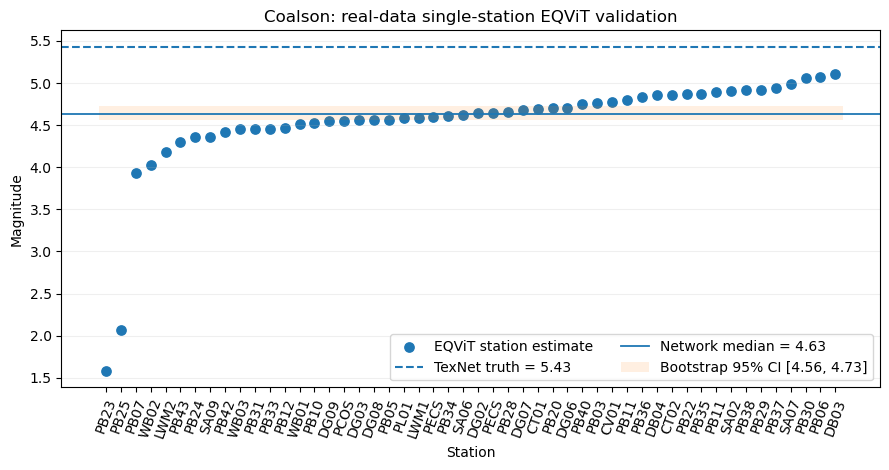

In [10]:
order=pred.sort_values("predicted_magnitude")
fig,ax=plt.subplots(figsize=(9,4.8)); x=np.arange(len(order))
ax.scatter(x,order.predicted_magnitude,s=45,label="EQViT station estimate")
ax.axhline(TRUE_M,ls="--",lw=1.5,label=f"TexNet truth = {TRUE_M:.2f}")
ax.axhline(M_median,lw=1.3,label=f"Network median = {M_median:.2f}")
ax.fill_between([-.5,len(order)-.5],ci_lo,ci_hi,alpha=.12,label=f"Bootstrap 95% CI [{ci_lo:.2f}, {ci_hi:.2f}]")
ax.set_xticks(x); ax.set_xticklabels(order.station,rotation=70)
ax.set(xlabel="Station",ylabel="Magnitude",title="Coalson: real-data single-station EQViT validation")
ax.grid(axis="y",alpha=.2); ax.legend(ncol=2); plt.tight_layout(); plt.show()

## 8. Residual diagnostics: distance, amplitude, and signal quality

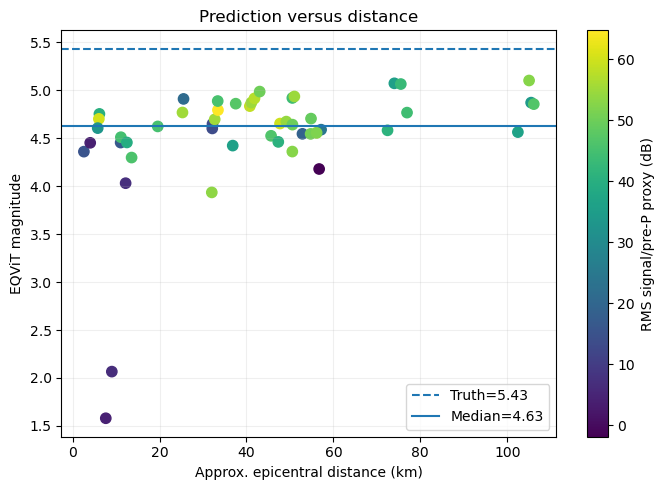

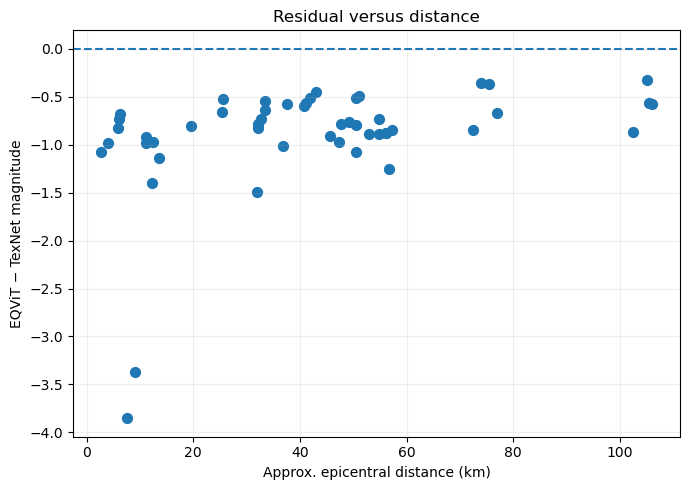

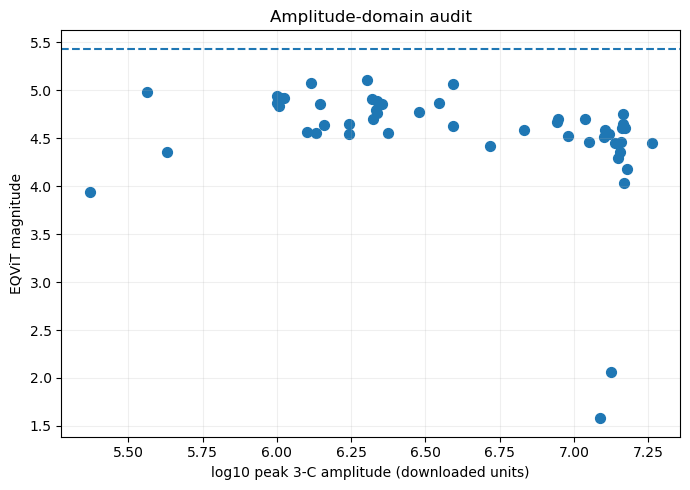

In [11]:
fig,ax=plt.subplots(figsize=(7,5))
sc=ax.scatter(pred.distance_km_approx,pred.predicted_magnitude,c=pred.snr_proxy_db,s=55)
ax.axhline(TRUE_M,ls="--",label=f"Truth={TRUE_M:.2f}"); ax.axhline(M_median,label=f"Median={M_median:.2f}")
ax.set(xlabel="Approx. epicentral distance (km)",ylabel="EQViT magnitude",title="Prediction versus distance")
ax.grid(alpha=.2); ax.legend(); plt.colorbar(sc,ax=ax,label="RMS signal/pre-P proxy (dB)"); plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(pred.distance_km_approx,pred.residual,s=50); ax.axhline(0,ls="--")
ax.set(xlabel="Approx. epicentral distance (km)",ylabel="EQViT − TexNet magnitude",title="Residual versus distance")
ax.grid(alpha=.2); plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(7,5))
ax.scatter(np.log10(pred.peak_vector_counts.clip(lower=1e-20)),pred.predicted_magnitude,s=50)
ax.axhline(TRUE_M,ls="--")
ax.set(xlabel="log10 peak 3-C amplitude (downloaded units)",ylabel="EQViT magnitude",
       title="Amplitude-domain audit")
ax.grid(alpha=.2); plt.tight_layout(); plt.show()

## 9. Waveform QC for representative best/worst station estimates

The plotted traces are normalized **only for display**. The inference tensors above are not normalized.

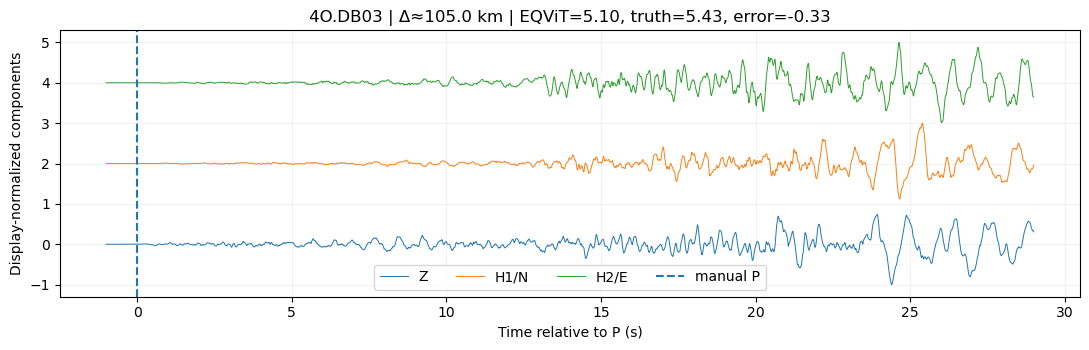

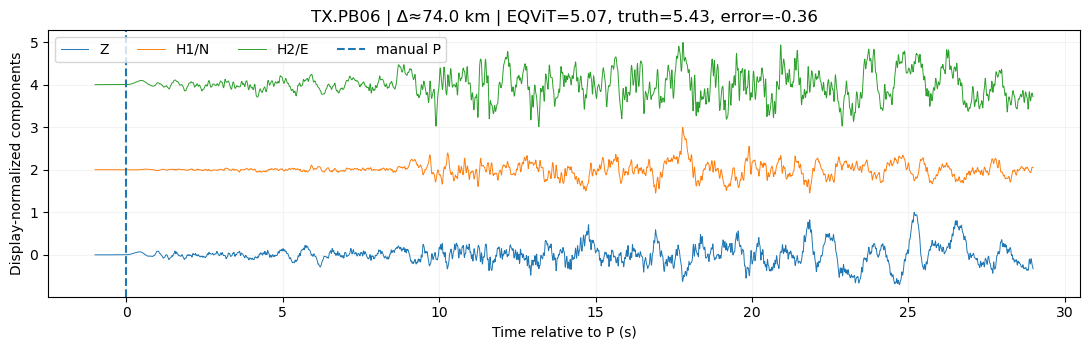

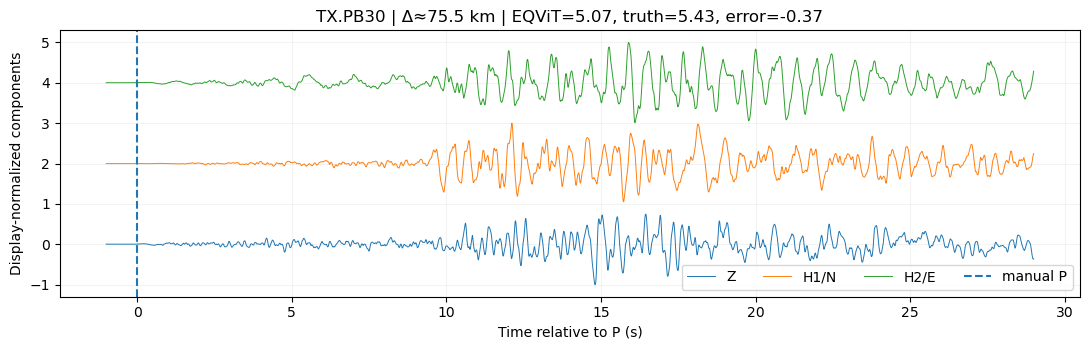

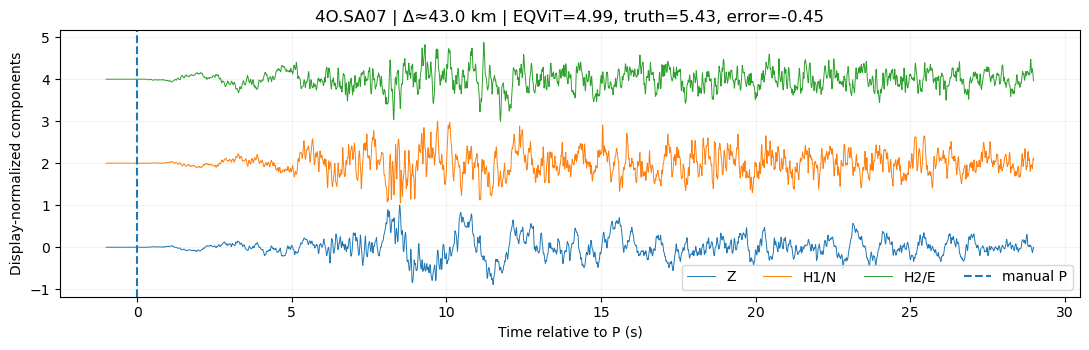

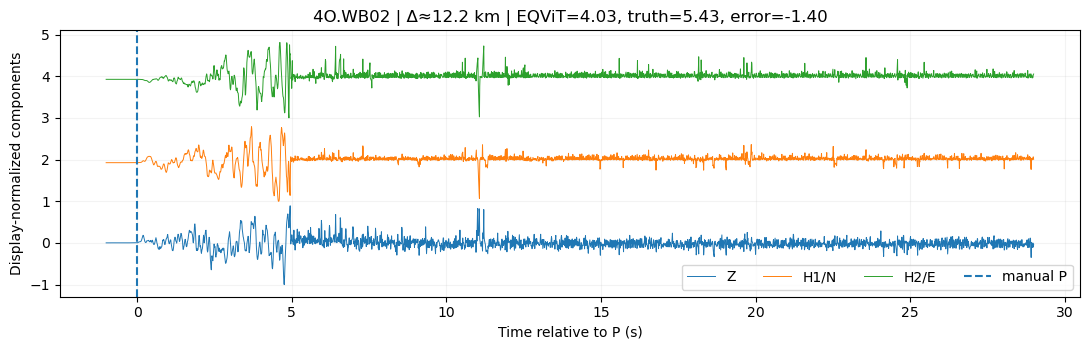

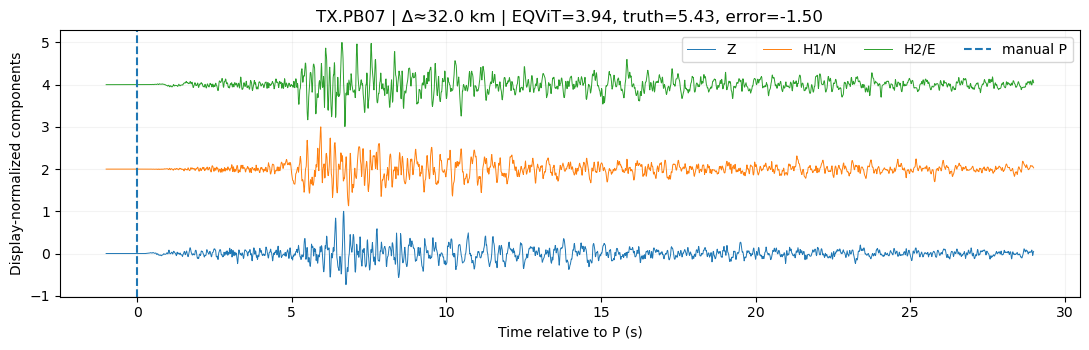

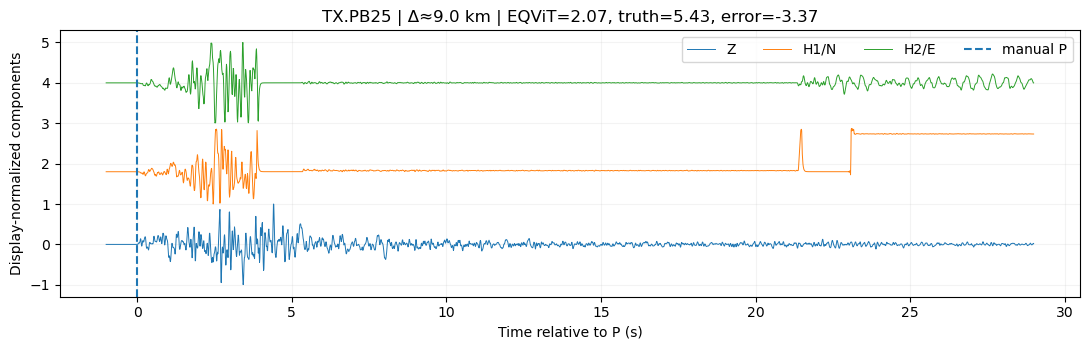

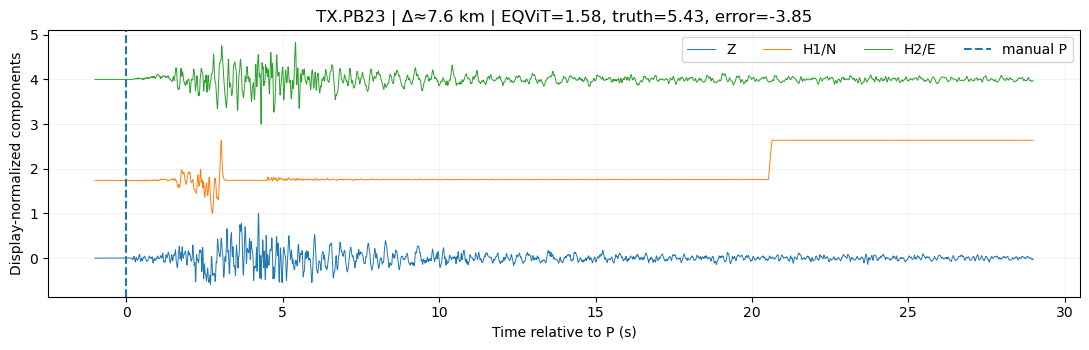

In [12]:
s=pred.sort_values("abs_error")
idx=list(s.head(min(4,len(s))).index)+list(s.tail(min(4,len(s))).index)
for i in dict.fromkeys(idx):
    r=pred.loc[i]; w=windows[(r.network,r.station)]; t=np.arange(N_SAMPLES)/FS-PRE_P_S
    scale=np.max(np.abs(w),axis=0); scale[scale==0]=1
    fig,ax=plt.subplots(figsize=(11,3.6))
    for j,lab in enumerate(["Z","H1/N","H2/E"]): ax.plot(t,w[:,j]/scale[j]+2*j,lw=.7,label=lab)
    ax.axvline(0,ls="--",label="manual P")
    ax.set(xlabel="Time relative to P (s)",ylabel="Display-normalized components",
           title=f"{r.network}.{r.station} | Δ≈{r.distance_km_approx:.1f} km | EQViT={r.predicted_magnitude:.2f}, truth={TRUE_M:.2f}, error={r.residual:+.2f}")
    ax.grid(alpha=.15); ax.legend(ncol=4); plt.tight_layout(); plt.show()

## 10. Causal EEW convergence of the P+29 s model

A station estimate is not available until its 29 s of post-P data have arrived. Sorting by `P arrival + 29 s` gives an honest latency trajectory without exposing future samples.

,n_stations,elapsed_s,network_median,network_mean,abs_error_median,last_station
0,1,30.676115,4.360403,4.360403,1.072576,PB24
1,2,30.774789,4.406424,4.406424,1.026555,WB03
2,3,31.054863,4.452445,4.522266,0.980534,PB40
3,4,31.091955,4.577264,4.567220,0.855714,PB20
4,5,31.167740,4.605797,4.574936,0.827181,PB34
5,6,31.324544,4.529121,4.075732,0.903857,PB23
6,7,31.437314,4.452445,3.788648,0.980534,PB25
7,8,31.867251,4.453739,3.871947,0.979239,PB31
8,9,31.878869,4.455034,3.942944,0.977944,WB01
9,10,31.914003,4.455630,3.994272,0.977348,PB33


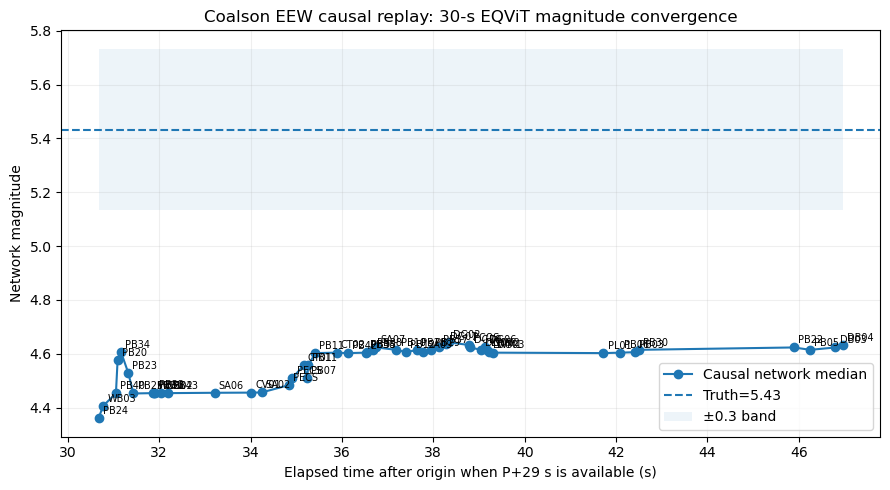

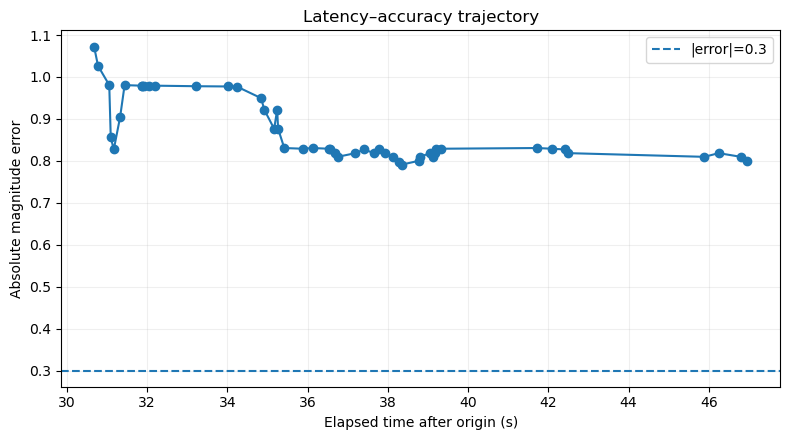

In [13]:
eew=pred.sort_values("available_at_elapsed_s").reset_index(drop=True)
run=[]
for i in range(len(eew)):
    z=eew.iloc[:i+1]
    run.append(dict(n_stations=i+1,elapsed_s=float(z.available_at_elapsed_s.iloc[-1]),
                    network_median=float(z.predicted_magnitude.median()),
                    network_mean=float(z.predicted_magnitude.mean()),
                    abs_error_median=float(abs(z.predicted_magnitude.median()-TRUE_M)),
                    last_station=z.station.iloc[-1]))
running=pd.DataFrame(run); running.to_csv(OUTPUT_DIR/"eew_causal_convergence.csv",index=False)
display(running)

fig,ax=plt.subplots(figsize=(9,5))
ax.plot(running.elapsed_s,running.network_median,marker="o",label="Causal network median")
ax.axhline(TRUE_M,ls="--",label=f"Truth={TRUE_M:.2f}")
ax.fill_between(running.elapsed_s,TRUE_M-.3,TRUE_M+.3,alpha=.08,label="±0.3 band")
for r in running.itertuples(): ax.annotate(r.last_station,(r.elapsed_s,r.network_median),xytext=(3,3),textcoords="offset points",fontsize=7)
ax.set(xlabel="Elapsed time after origin when P+29 s is available (s)",ylabel="Network magnitude",
       title="Coalson EEW causal replay: 30-s EQViT magnitude convergence")
ax.grid(alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(8,4.5))
ax.plot(running.elapsed_s,running.abs_error_median,marker="o"); ax.axhline(.3,ls="--",label="|error|=0.3")
ax.set(xlabel="Elapsed time after origin (s)",ylabel="Absolute magnitude error",title="Latency–accuracy trajectory")
ax.grid(alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

## 11. Sensitivity to the number of available stations

,n_stations,median_estimate,p025,p975,median_abs_error
0,1,4.642084,2.066149,5.072921,0.790894
1,2,4.639798,3.088483,4.970679,0.793180
2,3,4.623419,4.179361,4.920365,0.809559
3,4,4.647751,4.318210,4.896024,0.785227
4,5,4.623419,4.361121,4.910313,0.809559
5,8,4.636598,4.459108,4.853499,0.796380
6,10,4.627787,4.490936,4.826273,0.805191
7,15,4.632751,4.525646,4.768764,0.800227
8,20,4.627787,4.551425,4.746164,0.805191
9,50,4.632751,4.632751,4.632751,0.800227


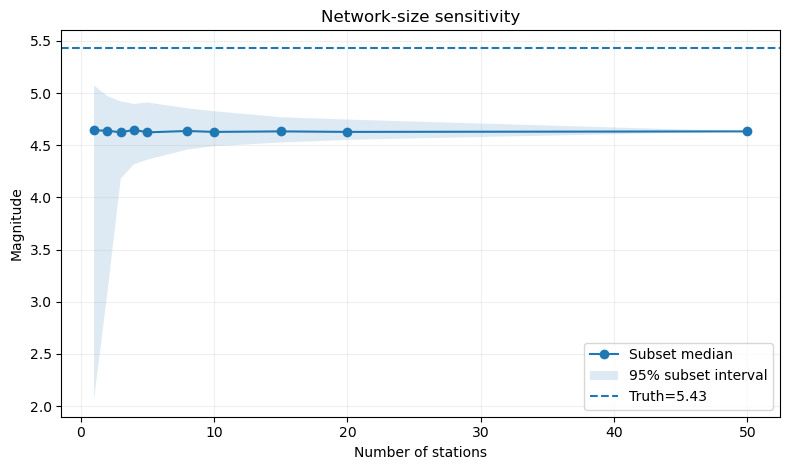

In [14]:
sizes=sorted(set([1,2,3,4,5,8,10,15,20,len(pred)])); sizes=[n for n in sizes if n<=len(pred)]
rows=[]; B=1500
for n in sizes:
    sims=np.array([np.median(v[rng.choice(len(v),size=n,replace=False)]) for _ in range(B)])
    rows.append(dict(n_stations=n,median_estimate=float(np.median(sims)),
                     p025=float(np.quantile(sims,.025)),p975=float(np.quantile(sims,.975)),
                     median_abs_error=float(np.median(np.abs(sims-TRUE_M)))))
stab=pd.DataFrame(rows); stab.to_csv(OUTPUT_DIR/"station_subset_stability.csv",index=False); display(stab)
fig,ax=plt.subplots(figsize=(8,4.8))
ax.plot(stab.n_stations,stab.median_estimate,marker="o",label="Subset median")
ax.fill_between(stab.n_stations,stab.p025,stab.p975,alpha=.15,label="95% subset interval")
ax.axhline(TRUE_M,ls="--",label=f"Truth={TRUE_M:.2f}")
ax.set(xlabel="Number of stations",ylabel="Magnitude",title="Network-size sensitivity")
ax.grid(alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

## 12. Headline metrics and EEW interpretation

For EEW, the decisive result is not only magnitude error but **when that accuracy becomes available**. The P+29 s model is naturally a late update/confirmation estimator. A fair next experiment is to train independent P+2, P+4, P+6, P+10, and P+20 s models and run the same Coalson replay. Do not simply zero/truncate this 30-s model: each horizon should be trained for its own input distribution.

In [15]:
final=pd.DataFrame([
 ["TexNet catalog magnitude",TRUE_M],
 ["Usable EQViT stations",len(pred)],
 ["EQViT network median",M_median],
 ["Median error",M_median-TRUE_M],
 ["EQViT 10% trimmed mean",M_trim],
 ["Station-level MAE",pred.abs_error.mean()],
 ["Station-level RMSE",np.sqrt(np.mean(pred.residual**2))],
 ["Bootstrap median CI low",ci_lo],["Bootstrap median CI high",ci_hi],
 ["First P+29 s estimate available (s after origin)",running.elapsed_s.min()],
 ["Final P+29 s station available (s after origin)",running.elapsed_s.max()],
],columns=["Metric","Value"])
display(final); final.to_csv(OUTPUT_DIR/"headline_metrics.csv",index=False)
print("Saved outputs:")
for p in sorted(OUTPUT_DIR.glob("*")): print(" ",p)

,Metric,Value
0,TexNet catalog magnitude,5.432978
1,Usable EQViT stations,50.000000
2,EQViT network median,4.632751
3,Median error,-0.800227
4,EQViT 10% trimmed mean,4.645438
5,Station-level MAE,0.897516
6,Station-level RMSE,1.083813
7,Bootstrap median CI low,4.557209
8,Bootstrap median CI high,4.728017
9,First P+29 s estimate available (s after origin),30.676115


Saved outputs:
  outputs/coalson_m54_eqvit_validation/download_log.csv
  outputs/coalson_m54_eqvit_validation/eew_causal_convergence.csv
  outputs/coalson_m54_eqvit_validation/event_validation_summary.json
  outputs/coalson_m54_eqvit_validation/headline_metrics.csv
  outputs/coalson_m54_eqvit_validation/rejected_stations.csv
  outputs/coalson_m54_eqvit_validation/station_predictions.csv
  outputs/coalson_m54_eqvit_validation/station_subset_stability.csv
  outputs/coalson_m54_eqvit_validation/waveforms
